In [2]:
import os

dataset_path = "/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/chest_xray"

print(os.listdir(dataset_path))

['val', 'test', 'train']


In [3]:
import os

train_path = "/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/chest_xray/train"

print(os.listdir(train_path))

['PNEUMONIA', 'NORMAL']


In [4]:
import os
import random

normal_path = "/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/chest_xray/train/NORMAL"
pneumonia_path = "/kaggle/input/datasets/jainam2511j/pneumonia/chest_xray/chest_xray/train/PNEUMONIA"

normal_images = random.sample(os.listdir(normal_path), 25)
pneumonia_images = random.sample(os.listdir(pneumonia_path), 25)

print("NORMAL Images :", len(normal_images))
print("PNEUMONIA Images :", len(pneumonia_images))
print("TOTAL Images :", len(normal_images) + len(pneumonia_images))

NORMAL Images : 25
PNEUMONIA Images : 25
TOTAL Images : 50


In [5]:
import cv2
import numpy as np

X = []
y = []

IMG_SIZE = 128

# NORMAL = 0
for img_name in normal_images:

    img_path = os.path.join(normal_path, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    X.append(img.flatten())
    y.append(0)

# PNEUMONIA = 1
for img_name in pneumonia_images:

    img_path = os.path.join(pneumonia_path, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    X.append(img.flatten())
    y.append(1)

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (50, 16384)
y Shape: (50,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 40
Testing Samples  : 10


In [8]:
#Logic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(lr_accuracy*100,2), "%")

Logistic Regression Accuracy: 100.0 %


In [9]:
#SVM
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", round(svm_accuracy*100,2), "%")

SVM Accuracy: 90.0 %


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy*100,2), "%")

Random Forest Accuracy: 100.0 %


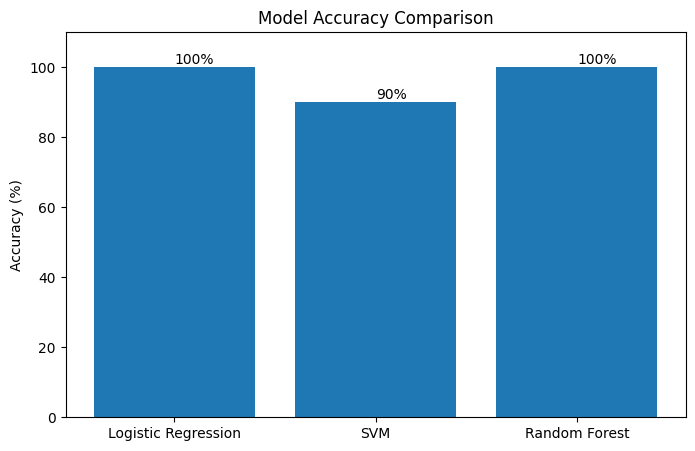

In [11]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "SVM",
    "Random Forest"
]

accuracies = [
    lr_accuracy * 100,
    svm_accuracy * 100,
    rf_accuracy * 100
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 1, f"{acc:.0f}%")

plt.show()

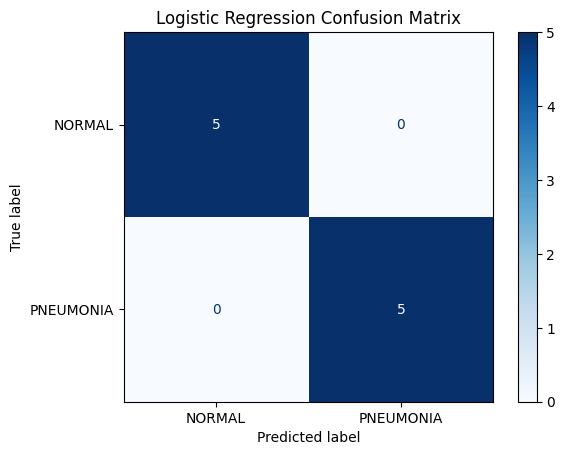

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.show()

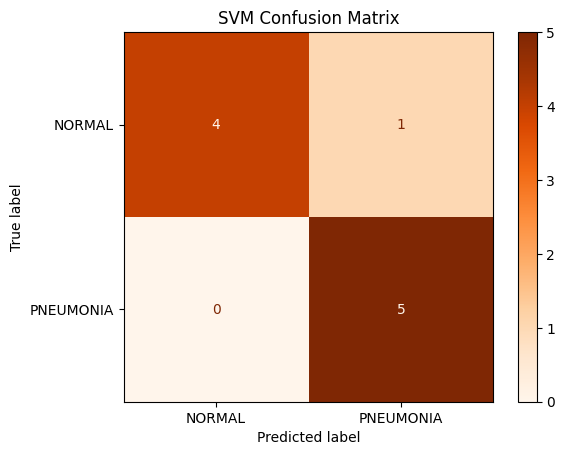

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Oranges")

plt.title("SVM Confusion Matrix")
plt.show()

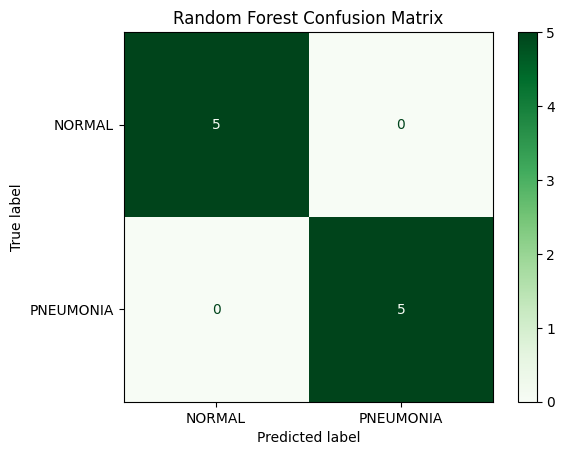

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["NORMAL", "PNEUMONIA"]
)

disp.plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")
plt.show()